In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
from rescue import ges_utils

In [5]:
positions, c2w_list, K_list, _, _ = ges_utils.convert_ges_to_mapanything_from_file('../generated/disaster_city_lawnmow_loop.json')


Parsed 2001 frames
X range (East):  0.0 to 140.1 m
Y range (North): -32.9 to 7.8 m
Z range (Alt):   -0.0 to 0.0 m


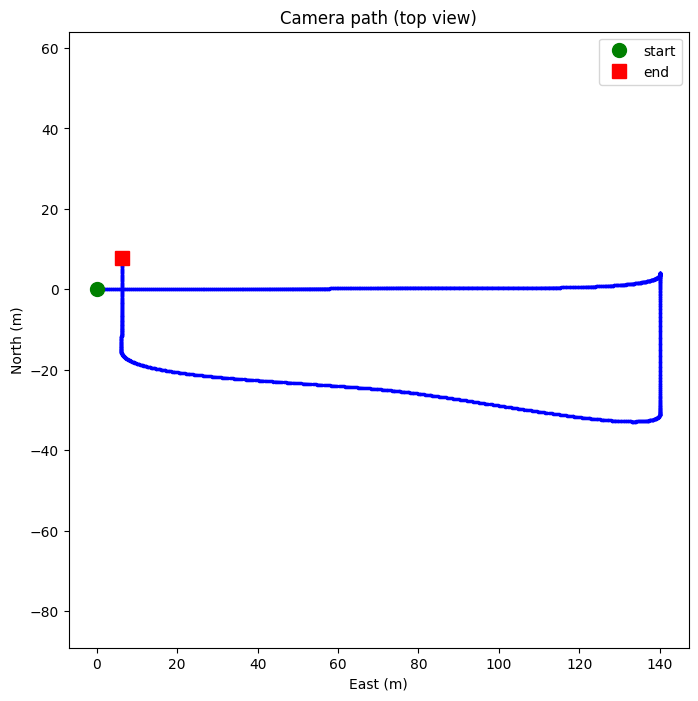

In [6]:
positions = np.array(positions)
print(f"\nParsed {len(positions)} frames")
print(f"X range (East):  {positions[:,0].min():.1f} to {positions[:,0].max():.1f} m")
print(f"Y range (North): {positions[:,1].min():.1f} to {positions[:,1].max():.1f} m")
print(f"Z range (Alt):   {positions[:,2].min():.1f} to {positions[:,2].max():.1f} m")

plt.figure(figsize=(8, 8))
plt.plot(positions[:, 0], positions[:, 1], "b.-", markersize=3)
plt.plot(positions[0, 0],  positions[0, 1],  "go", markersize=10, label="start")
plt.plot(positions[-1, 0], positions[-1, 1], "rs", markersize=10, label="end")
plt.xlabel("East (m)"); plt.ylabel("North (m)")
plt.title("Camera path (top view)"); plt.legend(); plt.axis("equal")
plt.show()

In [48]:
# import plotly.graph_objects as go

# # How long to draw each camera axis (in meters)
# AXIS_LEN = 30

# traces = []

# # --- Flight path ---
# traces.append(go.Scatter3d(
#     x=positions[:, 0], y=positions[:, 1], z=positions[:, 2],
#     mode="lines",
#     line=dict(color="royalblue", width=2),
#     name="flight path"
# ))

# # --- Start / end markers ---
# traces.append(go.Scatter3d(
#     x=[positions[0, 0]], y=[positions[0, 1]], z=[positions[0, 2]],
#     mode="markers", marker=dict(color="green", size=6), name="start"
# ))
# traces.append(go.Scatter3d(
#     x=[positions[-1, 0]], y=[positions[-1, 1]], z=[positions[-1, 2]],
#     mode="markers", marker=dict(color="red", size=6), name="end"
# ))

# # --- Camera frustums: draw 3 axes per camera ---
# # c2w columns: col 0 = X (right), col 1 = Y (up in ENU / down in cam), col 2 = Z (forward)
# # We draw forward (blue), right (red), up (green) as short lines from each camera center

# # Subsample cameras so the plot isn't too cluttered
# SHOW_EVERY = 5

# x_fwd, y_fwd, z_fwd = [], [], []  # forward axis lines (Z col)
# x_rgt, y_rgt, z_rgt = [], [], []  # right axis lines   (X col)
# x_up,  y_up,  z_up  = [], [], []  # up axis lines      (Y col)

# for c2w in c2w_list[::SHOW_EVERY]:
#     origin = c2w[:3, 3]
#     right   = c2w[:3, 0]   # camera X
#     up      = c2w[:3, 1]   # camera Y  (note: in OpenCV this is "down", but in ENU it's actual up)
#     forward = c2w[:3, 2]   # camera Z = pointing direction

#     for lst, direction in [(x_fwd, forward), (x_rgt, right), (x_up, up)]:
#         pass  # build below

#     def add_axis(xs, ys, zs, direction):
#         tip = origin + direction * AXIS_LEN
#         xs += [origin[0], tip[0], None]
#         ys += [origin[1], tip[1], None]
#         zs += [origin[2], tip[2], None]

#     add_axis(x_fwd, y_fwd, z_fwd, forward)
#     add_axis(x_rgt, y_rgt, z_rgt, right)
#     add_axis(x_up,  y_up,  z_up,  up)

# traces.append(go.Scatter3d(x=x_fwd, y=y_fwd, z=z_fwd,
#     mode="lines", line=dict(color="blue", width=2), name="cam forward (Z)"))
# traces.append(go.Scatter3d(x=x_rgt, y=y_rgt, z=z_rgt,
#     mode="lines", line=dict(color="red",  width=1), name="cam right (X)"))
# traces.append(go.Scatter3d(x=x_up,  y=y_up,  z=z_up,
#     mode="lines", line=dict(color="green", width=1), name="cam up (Y)"))

# fig = go.Figure(traces)
# fig.update_layout(
#     scene=dict(
#         xaxis_title="East (m)",
#         yaxis_title="North (m)",
#         zaxis_title="Up (m)",
#         aspectmode="data",       # preserves real-world proportions
#     ),
#     legend=dict(x=0, y=1),
#     margin=dict(l=0, r=0, t=30, b=0),
#     width=900, height=700,
#     title="Camera flight path + orientations"
# )
# fig.show()
